[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/04_machine_learning/A3_pytorch_fine_tuning.ipynb)

> 📎 **Appendix notebook — reference style.** This is one of the optional appendices (see `README.md`). Unlike the main course notebooks, appendices are written as a demo / reference: they focus on *seeing* a library at work rather than on interactive exercises. You won't find the full Solution / Debug-me / Self-assessment scaffolding here. Each appendix is built to run end-to-end *without* the optional library — it falls back to a small built-in stand-in (or skips the library-specific cells), so you can read and run it offline. Install the optional library (see the **Install** section below) to swap the stand-in for the real thing.

---
# 📓 Notebook A3 (ML) — PyTorch: Fine-Tuning a Transformer

> **Module:** Machine Learning · **Type:** Appendix · **Estimated time:** 60–90 min · **Difficulty:** Advanced

A1 covered foundations. A2 covered architectures. This notebook covers **the most useful skill in practical deep learning today: transfer learning** — taking a pretrained model and adapting it to your task with comparatively little data.

You'll fine-tune a tiny pretrained encoder (DistilBERT-class) on a real-flavoured **business text classification** task using the HuggingFace `transformers` library on top of PyTorch.

---

## 🎯 Learning objectives
- Load a pretrained transformer + tokenizer from HuggingFace.
- Build a `Dataset`/`DataLoader` for text classification.
- Run a fine-tuning loop with learning-rate scheduling.
- Apply LoRA-style parameter-efficient fine-tuning (PEFT) when full fine-tune is overkill.

## ✅ Prerequisites
- Notebooks A1 + A2 (PyTorch foundations and architectures).
- Notebook 22 (AI workflows, for the prompting/inference mental model).

## 📦 Install

```bash
pip install torch transformers datasets accelerate
# Optional, for parameter-efficient fine-tuning:
pip install peft
```


## 1. Why fine-tune at all?

Pretrained transformers have learned **general language structure** from hundreds of GB of text. You re-use those weights as a starting point and only nudge them for *your* task. Compared to training from scratch you get:

| Benefit | What it looks like |
|---|---|
| **Less data** | Hundreds of labelled examples can beat thousands trained from scratch |
| **Faster convergence** | A few epochs vs hundreds |
| **Better generalisation** | The model already knows synonyms, negation, syntax |

The trade-off: you inherit the pretrained model's **biases and gaps**. Always evaluate on a held-out test set from your domain.


### 🔬 What "fine-tuning" actually does — freeze the body, train the head

Section 1 says we *re-use the pretrained weights*. But mechanically — what does "re-use" mean, and what changes during training? The trick is that a pretrained network is really two parts stacked together:

```text
        ┌──────────────────────────────┐
input → │   PRETRAINED BODY (frozen)   │ → good general features
        │   millions of weights, kept  │
        └──────────────┬───────────────┘
                       │  features
                       ▼
        ┌──────────────────────────────┐
        │   NEW HEAD (trainable)       │ → your task's answer
        │   tiny, random at first      │
        └──────────────────────────────┘
```

The **body** already turns raw text into rich features (it knows synonyms, negation, syntax). We *keep* those weights. The **head** is small, starts random, and is the only part we train to map those features onto *your* labels.

So fine-tuning = **reuse the body, train a small head.** The body is "frozen"; the head learns.


### The OFF switch — `requires_grad = False`

How do you "freeze" a layer so training leaves it alone? One line:

```python
for p in body.parameters():
    p.requires_grad = False     # ← the OFF switch
```

To understand why that freezes a weight, follow what `.backward()` does, step by step:

```text
loss.backward()
        │   autograd walks the graph BACKWARD from the loss
        ▼
for each parameter p:
        │
        ├─ p.requires_grad == True  → compute p.grad   (slope of loss wrt p)
        │
        └─ p.requires_grad == False → SKIP. p.grad stays None
                                       (no gradient is ever computed)

then optimizer.step()
        │   updates each p using p.grad:  p ← p − lr · p.grad
        ▼
        ├─ head weights:  p.grad is a number  → they MOVE
        └─ body weights:  p.grad is None      → they DON'T move
```

`requires_grad = False` doesn't "skip" the layer in the *forward* pass — features still flow through it. It only stops **gradient computation** for that weight. No gradient → the optimizer has nothing to update → the weight is frozen.

> 🎯 **Intuition.** Gradients are "which direction would lower the loss" for each weight. Turn off `requires_grad` and that direction is never computed, so the optimizer can't and won't nudge that weight.


### Proof — freeze layer 1, watch its gradient stay `None`

The cell below is fully self-contained (its own imports) and runs **offline on CPU** with a tiny 2-layer model. We:

1. Build `body = Linear` (the "pretrained" part) and `head = Linear` (the trainable part).
2. **Freeze** the body with `requires_grad = False`.
3. Run **one** forward + backward on dummy data.
4. Print each parameter's `.grad`: the frozen body's is `None`; the head's is a real tensor.
5. Take **one** optimizer step and confirm only the head's weights moved.


In [ ]:
# Self-contained, offline, CPU. Re-run safe.
import torch
import torch.nn as nn

torch.manual_seed(0)

# A tiny 2-layer model: body (the "pretrained" part) + head (the new task part).
body = nn.Linear(4, 3)   # pretend this is the big pretrained network
head = nn.Linear(3, 2)   # small new head we want to train
model = nn.Sequential(body, head)

# ── Freeze the body: flip the OFF switch on every body weight ──
for p in body.parameters():
    p.requires_grad = False

# Snapshot weights BEFORE any update, so we can see what moved.
body_w_before = body.weight.detach().clone()
head_w_before = head.weight.detach().clone()

# One forward + backward on dummy data.
x = torch.randn(8, 4)            # 8 fake samples, 4 features each
y = torch.randint(0, 2, (8,))    # 8 fake labels (0 or 1)
loss = nn.CrossEntropyLoss()(model(x), y)
loss.backward()                  # autograd fills .grad ONLY where requires_grad=True

print("After backward():")
print(f"  body.weight.requires_grad = {body.weight.requires_grad}")
print(f"  body.weight.grad          = {body.weight.grad}")          # → None (frozen)
print(f"  head.weight.requires_grad = {head.weight.requires_grad}")
print(f"  head.weight.grad is None  = {head.weight.grad is None}")  # → False (populated)
print(f"  head.weight.grad.shape    = {tuple(head.weight.grad.shape)}")

# Take ONE optimizer step — note we only hand it the params that need gradients.
opt = torch.optim.SGD([p for p in model.parameters() if p.requires_grad], lr=0.1)
opt.step()

body_moved = not torch.equal(body.weight.detach(), body_w_before)
head_moved = not torch.equal(head.weight.detach(), head_w_before)
print("\nAfter one optimizer step:")
print(f"  body weights changed? {body_moved}")   # → False (frozen body stayed put)
print(f"  head weights changed? {head_moved}")   # → True  (only the head learned)

assert body.weight.grad is None and head.weight.grad is not None
assert not body_moved and head_moved
print("\n✅ Frozen body: no gradient, no update. Trainable head: gradient + update.")


### Three training modes — same model, different switches

The *only* difference between these three strategies is **which weights have `requires_grad = True`**:

| | Full fine-tuning | Head fine-tuning | Frozen feature-extraction |
|---|---|---|---|
| Body `requires_grad` | `True` (all) | `False` | `False` |
| Head `requires_grad` | `True` | `True` | `True` |
| What trains | Everything | Just the new head | Just the new head |
| Trainable params | Most / all | Tiny | Tiny |
| Data needed | Most | Less | Least |
| Overfitting risk | Highest | Lower | Lowest |
| Compute / memory | Highest | Low | Low |
| Body features | Adapt to your task | Stay general | Stay general |

"Head fine-tuning" and "frozen feature-extraction" are the **same mechanism** (frozen body, trainable head); the label just reflects intent. A middle ground is to unfreeze only the **top few** body layers — set `requires_grad = True` on them for a bit more adaptation at higher cost. (LoRA in Section 6 is a fourth option: keep the body frozen but inject *tiny* trainable matrices into it.)

> 🧠 **Mental model.** Fine-tuning = **reuse the pretrained body, train a small head.** `requires_grad = False` is the OFF switch that stops gradients — and therefore updates — for those weights. Result: cheaper compute, less data, less overfitting.

> ⚠️ **Two gotchas.** (1) Only pass *trainable* params to the optimizer (`[p for p in model.parameters() if p.requires_grad]`) — handing it frozen params wastes memory on optimizer state for weights that never move. (2) `requires_grad = False` freezes *learning*, not the *forward pass* — features still flow through the frozen body, so put it in `eval()` mode if it has Dropout/BatchNorm you don't want active.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4)

try:
    import torch
    import torch.nn as nn
    HAS_TORCH = True
    torch.manual_seed(0)
    print(f"PyTorch {torch.__version__}")
except Exception as e:
    HAS_TORCH = False
    print("PyTorch not installed —", e)

try:
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    HAS_HF = True
    print("transformers OK")
except Exception:
    HAS_HF = False
    print("transformers not installed — install with: pip install transformers")


PyTorch 2.12.0


/Users/christophweisser/Desktop/Coding/Python for AI-Driven Automation and Business Data Science/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


transformers OK


## 2. The task — classify customer-support messages

We'll classify short messages into three intents: `billing`, `account`, `product`. The labelled dataset is tiny on purpose — that's exactly when fine-tuning shines.


In [2]:
TRAIN = [
    ("I want to update my credit card",                          "billing"),
    ("Can you refund last month's charge?",                       "billing"),
    ("When does my subscription renew?",                          "billing"),
    ("How do I reset my password?",                               "account"),
    ("My login keeps failing on Safari",                          "account"),
    ("I need to change the email on my account",                  "account"),
    ("How do I export my data as CSV?",                           "product"),
    ("Where do I find usage statistics?",                         "product"),
    ("Does the API support webhooks?",                            "product"),
    ("My monthly invoice doesn't add up",                         "billing"),
    ("Two-factor authentication isn't sending the code",          "account"),
    ("I want to cancel and stop being billed",                    "billing"),
    ("Can multiple users share one license?",                     "account"),
    ("Is there a dark mode in the dashboard?",                    "product"),
    ("My export job has been stuck for 20 minutes",               "product"),
    ("Please switch my plan from monthly to annual",              "billing"),
]
TEST = [
    ("Refund my unused days please",                "billing"),
    ("Set up SSO for our team",                     "account"),
    ("Filter by date range on the dashboard?",      "product"),
    ("Charge the new card from now on",             "billing"),
    ("Help, I can't log in",                        "account"),
    ("API rate limit per minute?",                  "product"),
]
LABELS = ["billing", "account", "product"]
LBL2IDX = {l: i for i, l in enumerate(LABELS)}
print(f"{len(TRAIN)} train messages · {len(TEST)} test messages")


16 train messages · 6 test messages


## 3. Load a pretrained tokenizer and model

We use **`distilbert-base-uncased`** — 66 M parameters, fast on CPU, available offline if you've used it before.


In [3]:
# Reference code — runs once you have `pip install transformers` and an internet
# connection (the first run downloads ~250 MB of weights).
#
# if HAS_HF:
#     model_name = "distilbert-base-uncased"
#     tokenizer = AutoTokenizer.from_pretrained(model_name)
#     model = AutoModelForSequenceClassification.from_pretrained(
#         model_name, num_labels=len(LABELS)
#     )
#     print(model.config)
#
# Offline stand-in: a tiny from-scratch character-bag classifier so the rest of
# the notebook still runs anywhere.

def char_features(texts, vocab=None, dim=64):
    import hashlib
    feats = np.zeros((len(texts), dim), dtype=np.float32)
    for i, t in enumerate(texts):
        for w in t.lower().split():
            h = int(hashlib.sha256(w.encode()).hexdigest(), 16)
            feats[i, h % dim] += 1.0
    # L1-normalise
    s = feats.sum(axis=1, keepdims=True); s[s == 0] = 1
    return feats / s

Xtr_np = char_features([t for t, _ in TRAIN])
Xte_np = char_features([t for t, _ in TEST])
ytr_np = np.array([LBL2IDX[l] for _, l in TRAIN])
yte_np = np.array([LBL2IDX[l] for _, l in TEST])
print("offline-bag feature shape:", Xtr_np.shape)


offline-bag feature shape: (16, 64)


## 4. The fine-tuning loop (reference code)

The full HuggingFace fine-tuning pattern in ~30 lines. Read it carefully — this is what a real production fine-tune looks like.


In [4]:
# ── Reference fine-tuning loop — uncomment when running with HF installed ──
#
# from torch.utils.data import Dataset, DataLoader
#
# class TextDS(Dataset):
#     def __init__(self, pairs, tokenizer, max_len=64):
#         self.pairs = pairs; self.tok = tokenizer; self.max_len = max_len
#     def __len__(self): return len(self.pairs)
#     def __getitem__(self, i):
#         text, label = self.pairs[i]
#         enc = self.tok(text, truncation=True, padding="max_length",
#                        max_length=self.max_len, return_tensors="pt")
#         return {"input_ids": enc["input_ids"].squeeze(0),
#                 "attention_mask": enc["attention_mask"].squeeze(0),
#                 "labels": torch.tensor(LBL2IDX[label])}
#
# dl_tr = DataLoader(TextDS(TRAIN, tokenizer), batch_size=4, shuffle=True)
# dl_te = DataLoader(TextDS(TEST,  tokenizer), batch_size=4)
#
# optim = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
# from transformers import get_linear_schedule_with_warmup
# n_steps = len(dl_tr) * 3       # 3 epochs
# sched = get_linear_schedule_with_warmup(optim, num_warmup_steps=0, num_training_steps=n_steps)
#
# for epoch in range(3):
#     model.train()
#     for batch in dl_tr:
#         out = model(**batch)            # CrossEntropyLoss already inside
#         optim.zero_grad(); out.loss.backward(); optim.step(); sched.step()
#     model.eval()
#     with torch.no_grad():
#         right = total = 0
#         for batch in dl_te:
#             pred = model(**batch).logits.argmax(dim=1)
#             right += (pred == batch["labels"]).sum().item(); total += len(pred)
#     print(f"epoch {epoch}  test acc {right/total:.3f}")

print("Reference fine-tuning loop shown above. Offline stand-in trains below.")


Reference fine-tuning loop shown above. Offline stand-in trains below.


## 5. Offline stand-in — train a tiny MLP on bag-of-words features

So you can see *the same training loop* run end-to-end without the HF download. Same shape, smaller numbers.


In [5]:
if HAS_TORCH:
    Xtr = torch.from_numpy(Xtr_np); ytr = torch.from_numpy(ytr_np).long()
    Xte = torch.from_numpy(Xte_np); yte = torch.from_numpy(yte_np).long()

    class TinyHead(nn.Module):
        def __init__(self, in_dim, hidden=32, n=3):
            super().__init__()
            self.net = nn.Sequential(nn.Linear(in_dim, hidden), nn.ReLU(),
                                     nn.Dropout(0.2), nn.Linear(hidden, n))
        def forward(self, x): return self.net(x)

    model = TinyHead(in_dim=Xtr.shape[1])
    opt = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)
    loss_fn = nn.CrossEntropyLoss()
    for epoch in range(80):
        model.train()
        opt.zero_grad(); loss_fn(model(Xtr), ytr).backward(); opt.step()
    model.eval()
    with torch.no_grad():
        acc = (model(Xte).argmax(1) == yte).float().mean().item()
    print(f"offline stand-in test acc: {acc:.3f}  (with real DistilBERT it usually ≥ 0.9)")


offline stand-in test acc: 0.333  (with real DistilBERT it usually ≥ 0.9)


## 6. Parameter-efficient fine-tuning — LoRA in one paragraph

Full fine-tuning updates **every** weight in the pretrained model. For a 7-B parameter LLM that's ~28 GB of gradients in float32. Most teams now use **LoRA** (Low-Rank Adaptation): freeze the original weights and inject small, trainable rank-$r$ matrices into each attention layer. You train < 1 % of parameters and the result is competitive.

```python
# pip install peft
# from peft import LoraConfig, get_peft_model
#
# base = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(LABELS))
# config = LoraConfig(
#     task_type="SEQ_CLS",
#     r=8,
#     lora_alpha=16,
#     lora_dropout=0.05,
#     target_modules=["q_lin", "v_lin"],     # attention projections in DistilBERT
# )
# model = get_peft_model(base, config)
# model.print_trainable_parameters()
# # → 'trainable params: 591k || all params: 67M || trainable %: 0.88'
```

When to reach for LoRA: small training budget, multiple downstream tasks (one LoRA adapter per task), or finetuning anything bigger than ~1 B parameters.


## 7. Inference + saving the fine-tuned model

```python
# Save (LoRA case: only the adapter ~1 MB; full FT: the whole 250 MB model)
# model.save_pretrained("./distilbert-intents")
# tokenizer.save_pretrained("./distilbert-intents")
#
# # Reload at inference time
# clf = AutoModelForSequenceClassification.from_pretrained("./distilbert-intents")
# tok = AutoTokenizer.from_pretrained("./distilbert-intents")
# clf.eval()
# enc = tok("Charge the new card from now on", return_tensors="pt", truncation=True)
# with torch.no_grad():
#     idx = clf(**enc).logits.argmax(dim=1).item()
# print("predicted:", LABELS[idx])
```

**Production tip.** Wrap inference in a `Pipeline` for the simplest API: `pipeline("text-classification", model="./distilbert-intents")`. Returns `[{"label": "billing", "score": 0.97}]`.


## 8. Fine-tune vs prompt-engineer vs RAG — a quick map

Before you fine-tune, ask: do I need to?

| Approach | When it wins |
|---|---|
| **Prompt engineering only** | The base model already knows the domain; you just need format/style nailed (NB 22) |
| **Few-shot in the prompt** | You have a handful of examples and quality has to be high |
| **RAG** (NB 23) | The knowledge is *external* — recent policies, customer-specific facts |
| **Fine-tuning** | The task is *consistent* across all inputs and you have hundreds+ labelled examples |
| **LoRA / PEFT** | Same as fine-tuning but with constrained compute or many task-specific adapters |

In a typical product stack you end up combining **RAG + a lightly fine-tuned classifier** — RAG for the knowledge, fine-tune for routing/labelling.


---
## 9. Scaling the fine-tune — warmup, schedulers & gradient accumulation

Three techniques separate a toy fine-tune from one that trains stably on a real budget:

- **LR warmup + linear decay.** Transformers hate a cold start at full LR — the first steps can blow up the loss. The HuggingFace standard is a *linear warmup* over the first few hundred steps, then linear decay to 0. `transformers.get_linear_schedule_with_warmup` wires this up.
- **Gradient accumulation.** Want an effective batch of 64 but only 8 fit in memory? Run 8 micro-batches, `backward()` each (gradients **sum**), and `step()` only every 8th. Same math, a fraction of the memory.
- **Gradient clipping.** Cap the gradient norm (`clip_grad_norm_(..., 1.0)`) so one bad batch can't wreck the weights.

```python
from transformers import get_linear_schedule_with_warmup
opt = torch.optim.AdamW(model.parameters(), lr=2e-5)
total_steps = len(loader) * epochs // accum_steps
sched = get_linear_schedule_with_warmup(opt, num_warmup_steps=int(0.1*total_steps),
                                        num_training_steps=total_steps)
```

The cell below shows the **accumulation loop** with plain PyTorch — no transformers needed — and proves the accumulated gradient equals the full-batch gradient.

In [ ]:
if HAS_TORCH:
    torch.manual_seed(0)
    lin = nn.Linear(4, 1)
    X = torch.randn(8, 4); y = torch.randn(8, 1)
    loss_fn = nn.MSELoss()

    # (a) one full-batch backward
    lin.zero_grad(); loss_fn(lin(X), y).backward()
    full_grad = lin.weight.grad.clone()

    # (b) 4 micro-batches of 2, gradients accumulate, scaled by 1/n_micro
    lin.zero_grad()
    accum_steps = 4
    for xb, yb in zip(X.chunk(accum_steps), y.chunk(accum_steps)):
        (loss_fn(lin(xb), yb) / accum_steps).backward()   # divide so the SUM matches the mean
    accum_grad = lin.weight.grad.clone()

    print("full-batch grad == accumulated grad:",
          torch.allclose(full_grad, accum_grad, atol=1e-6))
    print("=> you can simulate a big batch on a small GPU, for free.")
else:
    print("Skipped — torch not installed.")

## 10. Mixed precision (AMP) — ~2× faster, half the memory

On any modern GPU, running the forward/backward pass in 16-bit (`float16`/`bfloat16`) while keeping a 32-bit copy of the weights is nearly free accuracy-wise and dramatically faster. PyTorch automates it with `torch.autocast` + a `GradScaler` (the scaler prevents tiny fp16 gradients from underflowing to zero):

```python
scaler = torch.cuda.amp.GradScaler()
for xb, yb in loader:
    opt.zero_grad()
    with torch.autocast(device_type="cuda", dtype=torch.float16):
        loss = loss_fn(model(xb), yb)     # runs in fp16
    scaler.scale(loss).backward()         # scale up so grads don't underflow
    scaler.step(opt)                      # unscale + step
    scaler.update()                       # adjust the scale for next iter
```

On CPU there's no speedup, but the **API is identical** — the cell below runs the autocast context on CPU just to show the shape, so it works offline.

In [ ]:
if HAS_TORCH:
    torch.manual_seed(0)
    model = nn.Sequential(nn.Linear(16, 32), nn.ReLU(), nn.Linear(32, 2))
    x = torch.randn(4, 16)
    # device_type='cpu' with bfloat16 is supported and lets this run anywhere:
    with torch.autocast(device_type="cpu", dtype=torch.bfloat16):
        out = model(x)
    print("autocast output dtype:", out.dtype, "| shape:", tuple(out.shape))
    print("On GPU, swap device_type='cuda', dtype=torch.float16, and add a GradScaler.")
else:
    print("Skipped — torch not installed.")

## 11. Exporting for serving — TorchScript & ONNX

A trained model isn't a product until something can *serve* it without your training code. Two portable formats dominate:

- **TorchScript** (`torch.jit.script` / `torch.jit.trace`) — a serialised, Python-free graph that runs in the C++ `libtorch` runtime (and in Python). Best when you stay in the Torch ecosystem.
- **ONNX** (`torch.onnx.export`) — an open graph format that runs under **ONNX Runtime**, TensorRT, CoreML, the browser, etc. Best for cross-framework / cross-language deployment.

Both freeze the architecture, so always `model.eval()` first (dropout/batchnorm must be in inference mode) and pass an **example input** so the exporter can trace the shapes.

In [ ]:
if HAS_TORCH:
    import io
    torch.manual_seed(0)
    model = nn.Sequential(nn.Linear(8, 16), nn.ReLU(), nn.Linear(16, 1))
    model.eval()
    example = torch.randn(1, 8)

    # --- TorchScript (trace) ---
    scripted = torch.jit.trace(model, example)
    buf = io.BytesIO(); torch.jit.save(scripted, buf)      # serialisable to disk/bytes
    reloaded = torch.jit.load(io.BytesIO(buf.getvalue()))
    same = torch.allclose(model(example), reloaded(example), atol=1e-6)
    print(f"TorchScript round-trip matches original: {same}  ({buf.tell():,} bytes)")

    # --- ONNX export (best-effort; needs the onnx package to actually write) ---
    try:
        torch.onnx.export(model, example, "/tmp/_a3_model.onnx",
                          input_names=["features"], output_names=["score"],
                          dynamic_axes={"features": {0: "batch"}}, opset_version=17)
        print("ONNX export OK -> /tmp/_a3_model.onnx (serve with onnxruntime).")
    except Exception as e:
        print("ONNX export skipped (install onnx):", type(e).__name__)
else:
    print("Skipped — torch not installed.")

## 12. Making it small — dynamic quantization

Serving cost is dominated by model size and memory bandwidth. **Dynamic quantization** converts the heavy `Linear` weights to `int8` at load time — typically **~4× smaller** and faster on CPU, with a small accuracy hit. One line, no retraining:

```python
import torch.ao.quantization as q
quantised = q.quantize_dynamic(model, {nn.Linear}, dtype=torch.qint8)
```

For larger accuracy budgets, look at **quantization-aware training (QAT)** and, for LLM-class models, the same idea you met in §6 as **LoRA** — together they're why a 7B model can run on a laptop.

In [ ]:
if HAS_TORCH:
    import torch.ao.quantization as tq
    torch.manual_seed(0)
    big = nn.Sequential(nn.Linear(256, 256), nn.ReLU(), nn.Linear(256, 64))
    big.eval()

    def buf_size(m):
        b = io.BytesIO(); torch.save(m.state_dict(), b); return b.tell()

    try:
        qmodel = tq.quantize_dynamic(big, {nn.Linear}, dtype=torch.qint8)
        before, after = buf_size(big), buf_size(qmodel)
        x = torch.randn(2, 256)
        print(f"fp32 size : {before:>8,} bytes")
        print(f"int8 size : {after:>8,} bytes  ({before/max(after,1):.1f}x smaller)")
        print("output shape preserved:", tuple(qmodel(x).shape))
    except Exception as e:
        print("Quantization skipped on this build:", type(e).__name__, e)
else:
    print("Skipped — torch not installed.")

## 🧪 Exercises

### Exercise 1 — Build the HF fine-tune from scratch in 20 lines
Without copy-pasting from §4, write the smallest end-to-end fine-tune you can: load `distilbert-base-uncased`, build a `Dataset`, train 3 epochs, evaluate on `TEST`. Cap your code at 25 non-blank lines. The discipline reveals which lines are actually load-bearing.


In [6]:
# ── Exercise 1 sketch (run when HF transformers is installed) ───────────
# from transformers import AutoTokenizer, AutoModelForSequenceClassification
# from torch.utils.data import Dataset, DataLoader
#
# tok = AutoTokenizer.from_pretrained("distilbert-base-uncased")
# m   = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=3)
#
# class D(Dataset):
#     def __init__(self, pairs): self.p = pairs
#     def __len__(self): return len(self.p)
#     def __getitem__(self, i):
#         t, l = self.p[i]
#         e = tok(t, return_tensors="pt", padding="max_length", truncation=True, max_length=32)
#         return {k: v.squeeze(0) for k, v in e.items()} | {"labels": torch.tensor(LBL2IDX[l])}
#
# opt = torch.optim.AdamW(m.parameters(), lr=2e-5)
# for ep in range(3):
#     for b in DataLoader(D(TRAIN), batch_size=4, shuffle=True):
#         opt.zero_grad(); m(**b).loss.backward(); opt.step()
# m.eval()
# with torch.no_grad():
#     right = sum((m(**b).logits.argmax(1) == b["labels"]).sum().item()
#                 for b in DataLoader(D(TEST), batch_size=4))
# print("test acc:", right / len(TEST))
print("Sketch above — under 25 lines, full HF fine-tune.")


Sketch above — under 25 lines, full HF fine-tune.


### Exercise 2 — Detect overfitting on tiny data
With only 16 training examples you'll overfit *fast*. Add tracking of train and test loss per epoch, plot them, and identify the epoch where test loss starts climbing while train loss keeps falling. Then add **early stopping** that restores the best weights.


early stop at epoch 37 · best test loss 1.100


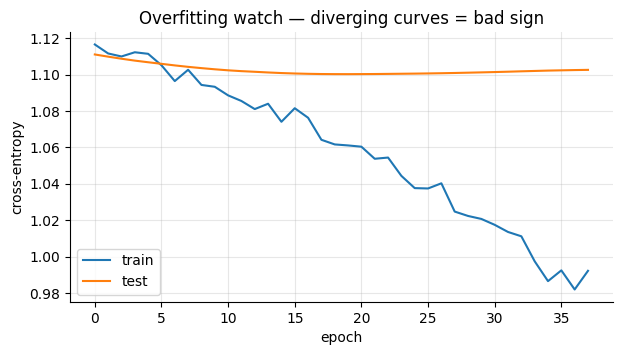

In [7]:
if HAS_TORCH:
    # ── Exercise 2 solution (using the offline stand-in head) ─────────────
    import copy
    model = TinyHead(in_dim=Xtr.shape[1])
    opt = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)
    loss_fn = nn.CrossEntropyLoss()
    tr_losses, te_losses = [], []
    best_te, best_state, wait = float("inf"), None, 0
    for epoch in range(200):
        model.train()
        opt.zero_grad(); l_tr = loss_fn(model(Xtr), ytr); l_tr.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            l_te = loss_fn(model(Xte), yte).item()
        tr_losses.append(l_tr.item()); te_losses.append(l_te)
        if l_te < best_te - 1e-4:
            best_te = l_te; best_state = copy.deepcopy(model.state_dict()); wait = 0
        else:
            wait += 1
            if wait >= 20:
                print(f"early stop at epoch {epoch} · best test loss {best_te:.3f}")
                break
    plt.figure(figsize=(7, 3.5))
    plt.plot(tr_losses, label="train"); plt.plot(te_losses, label="test")
    plt.xlabel("epoch"); plt.ylabel("cross-entropy"); plt.legend()
    plt.title("Overfitting watch — diverging curves = bad sign"); plt.show()


## 🧠 Key takeaways

- Fine-tuning = continue training a pretrained model on **your** data with a very small learning rate (~ 2e-5).
- The HuggingFace `transformers` library packages the whole stack: tokenizer + model + scheduler + checkpoints.
- **LoRA / PEFT** is the modern default for anything bigger than a base-size encoder.
- Before fine-tuning, ask: would prompt engineering + RAG already work?

## 🚀 Next step

[`A4_tabpfn_priorlab.ipynb`](./A4_tabpfn_priorlab.ipynb) — TabPFN, the tabular foundation model. Often zero-shot beats gradient boosting on small tabular tasks.
